# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import re
import os
import xml.etree.ElementTree as ET
from pathlib import Path
from PIL import Image

import torch
import torchvision
from torchvision import datasets, transforms
from torchvision.datasets import CIFAR10
from avalanche.benchmarks.classic import PermutedMNIST
from torchvision.models import alexnet
from torchvision.models import resnet18

import torch.nn as nn
from torch.nn import CrossEntropyLoss
from torch.optim import Adam
from torch.utils.data import Dataset, Subset
from torch.utils.data import random_split

from collections import Counter

from avalanche.benchmarks.classic import SplitMNIST, PermutedMNIST, SplitCIFAR10
from avalanche.benchmarks import nc_benchmark
from avalanche.models import SimpleMLP, SimpleCNN
from avalanche.models import pytorchcv_wrapper
from avalanche.models import as_multitask
from avalanche.training.supervised import Naive, Cumulative, EWC
from avalanche.training.plugins import EvaluationPlugin, ReplayPlugin
from avalanche.logging import InteractiveLogger, TextLogger
from avalanche.logging import TensorboardLogger
from avalanche.evaluation.metrics import (
    forgetting_metrics,
    accuracy_metrics,
    loss_metrics,
    cpu_usage_metrics,
    timing_metrics,
    gpu_usage_metrics,
    ram_usage_metrics,
    disk_usage_metrics,
    MAC_metrics,
    confusion_matrix_metrics,
)

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
device

ERROR! Session/line number was not unique in database. History logging moved to new session 2


device(type='cuda', index=0)

# CIFAR c AlexNet

### Загрузка датасета

In [4]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

transform = transforms.Compose(
        [
            transforms.ToTensor()
        ]
    )

In [5]:
trainset = CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = CIFAR10(root='./data', train=False, download=True, transform=transform)

In [6]:
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

In [7]:
print(f"Размер обучающей выборки: {len(trainset)}")
print(f"Размер тестовой выборки: {len(testset)}")
print("Форма одного изображения:", trainset[0][0].shape) # (C, H, W)

Размер обучающей выборки: 50000
Размер тестовой выборки: 10000
Форма одного изображения: torch.Size([3, 32, 32])


### Примеры изображений

In [8]:
def plot_images(images, labels, class_names, n_rows=2, n_cols=5):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 2.5 * n_rows))
    axes = axes.flatten()
    for i in range(n_rows * n_cols):
        img = images[i].permute(1, 2, 0).numpy()
        axes[i].imshow(img)
        axes[i].set_title(class_names[labels[i]], fontsize=10)
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

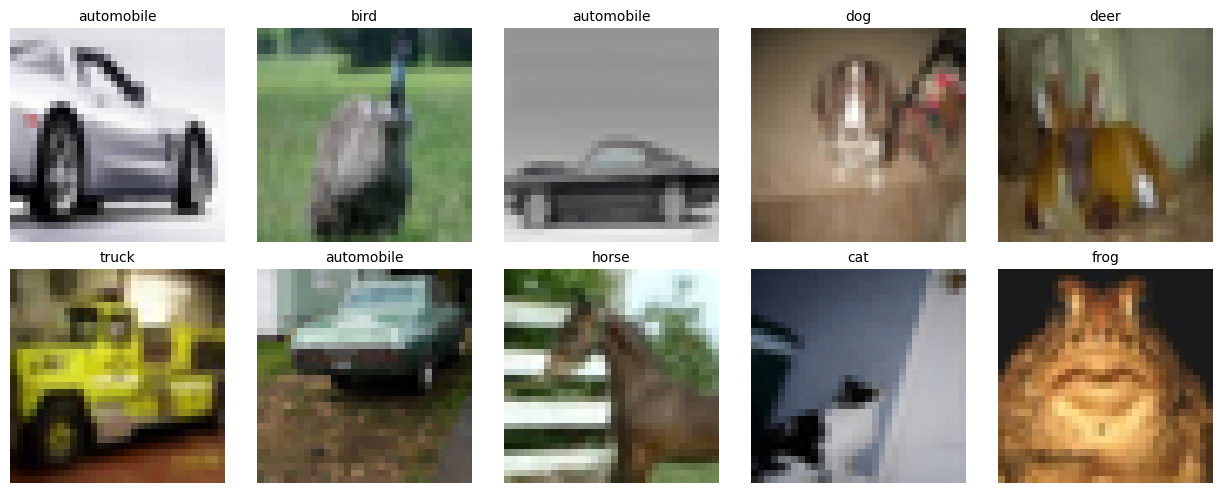

In [9]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

plot_images(images[:10], labels[:10], classes)

### Распределение классов

/tmp/ipykernel_430663/4212480098.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=class_names, y=class_values, palette='viridis')


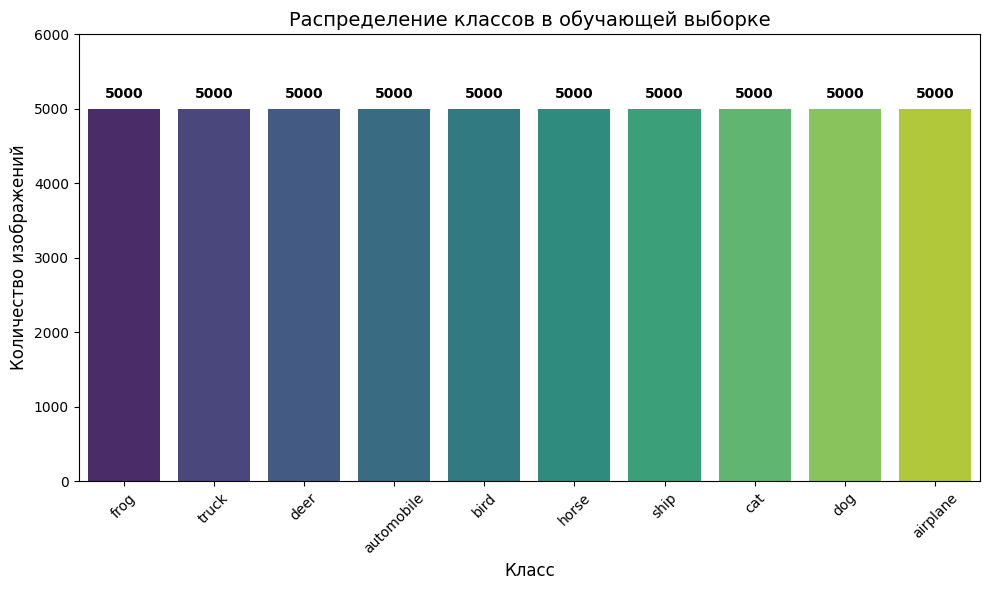

In [10]:
train_labels = [label for _, label in trainset]
class_counts = Counter(train_labels)
class_names = [classes[i] for i in class_counts.keys()]
class_values = list(class_counts.values())

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=class_names, y=class_values, palette='viridis')
for i, val in enumerate(class_values):
    ax.text(i, val + 100, str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
    
plt.title("Распределение классов в обучающей выборке", fontsize=14)
plt.ylabel("Количество изображений", fontsize=12)
plt.xlabel("Класс", fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, max(class_values) + 1000)
plt.tight_layout()
plt.show()

### Средние и стандартные отклонения по каналам

In [11]:
def get_mean_std(dataset):
    loader = torch.utils.data.DataLoader(dataset, batch_size=5000, shuffle=False)
    mean = 0.
    std = 0.
    for images, _ in loader:
        batch_samples = images.size(0)
        images = images.view(batch_samples, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
    mean /= len(dataset)
    std /= len(dataset)
    return mean, std
mean, std = get_mean_std(trainset)
print("Средние значения по каналам:", mean)
print("Стандартные отклонения:", std)

Средние значения по каналам: tensor([0.4914, 0.4822, 0.4465])
Стандартные отклонения: tensor([0.2023, 0.1994, 0.2010])


### Загружаем датасет с учетом среднего и стандартного отклонения

In [12]:
transform = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ]
    )

In [13]:
cifar_train = CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar_test = CIFAR10(root='./data', train=False, download=True, transform=transform)

### Создание модели

In [26]:
model = alexnet(weights=None)

# Модификация под CIFAR-10 (размер изображений 32x32 вместо 224x224)
model.features[0] = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)  # Уменьшаем ядро и шаг
model.classifier[-1] = nn.Linear(4096, 10)  # Заменяем выходной слой на 10 классов (CIFAR-10)

avalanche_alexnet = as_multitask(model, classifier_name="classifier")

In [27]:
# print(model)

In [28]:
benchmark = nc_benchmark(
    cifar_train,
    cifar_test,
    5,
    task_labels=False,
    seed=1234,
    fixed_class_order=[i for i in range(10)],
)

In [29]:
# choose some metrics and evaluation method
interactive_logger = InteractiveLogger()
tensorboard_logger = TensorboardLogger(tb_log_dir="./logs/")

eval_plugin = EvaluationPlugin(
    accuracy_metrics(minibatch=True, epoch=True, experience=True, stream=True),
    loss_metrics(minibatch=True, epoch=True, experience=True, stream=True),
    forgetting_metrics(experience=True),
    loggers=[interactive_logger, tensorboard_logger # wandb_logger
            ],
)

In [18]:
# CREATE THE STRATEGY INSTANCE (Naive, with Replay)
cl_strategy_naive = Naive(
    model=model,
    optimizer=torch.optim.SGD(model.parameters(), lr=0.01),
    criterion=CrossEntropyLoss(),
    train_mb_size=100,
    train_epochs=1,
    eval_mb_size=100,
    device=device,
    plugins=[ReplayPlugin(mem_size=1000)],
    evaluator=eval_plugin,
)

In [24]:
cl_strategy_ewc = EWC(
    model=model,
    optimizer=torch.optim.SGD(model.parameters(), lr=0.01),
    criterion=CrossEntropyLoss(),
    ewc_lambda=0.4,
    train_mb_size=100,
    train_epochs=1,
    eval_mb_size=100,
    device=device,
    plugins=[ReplayPlugin(mem_size=1000)],
    evaluator=eval_plugin,
)

In [30]:
cl_strategy_cumulative = Cumulative(
    model=model,
    optimizer=torch.optim.SGD(model.parameters(), lr=0.01),
    criterion=CrossEntropyLoss(),
    train_mb_size=100,
    train_epochs=1,
    eval_mb_size=100,
    device=device,
    plugins=[ReplayPlugin(mem_size=1000)],
    evaluator=eval_plugin,
)

In [19]:
# TRAINING LOOP
print("Starting experiment...")
results_cifar10_alexnet_naive = []
for experience in benchmark.train_stream:
    print("Start of experience ", experience.current_experience)
    cl_strategy_naive.train(experience)
    print("Training completed")

    print("Computing accuracy on the whole test set")
    results_cifar10_alexnet_naive.append(cl_strategy_naive.eval(benchmark.test_stream))

Starting experiment...
Start of experience  0
-- >> Start of training phase << --
100%|█████████████████████████████████████████| 100/100 [00:02<00:00, 35.14it/s]

/home/nikos/anaconda3/envs/myenv3/lib/python3.11/site-packages/avalanche/training/plugins/replay.py:123: DeprecationWarning: Call to deprecated function update (removal in version 0.7: switch to pre_adapt and post_adapt)
  self.storage_policy.update(strategy, **kwargs)



Epoch 0 ended.
	Loss_Epoch/train_phase/train_stream/Task000 = 4.0081
	Loss_MB/train_phase/train_stream/Task000 = 0.7864
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.4747
	Top1_Acc_MB/train_phase/train_stream/Task000 = 0.4500
-- >> End of training phase << --
Training completed
Computing accuracy on the whole test set
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 57.87it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	Loss_Exp/eval_phase/test_stream/Task000/Exp000 = 0.8697
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.5000
-- Starting eval on experience 1 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 50.16it/s]
> Eval on experience 1 (Task 0) from test stream ended.
	Loss_Exp/eval_phase/test_stream/Task000/Exp001 = 13.5234
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001 = 0.0000
-- St

/home/nikos/anaconda3/envs/myenv3/lib/python3.11/site-packages/avalanche/training/plugins/replay.py:123: DeprecationWarning: Call to deprecated function update (removal in version 0.7: switch to pre_adapt and post_adapt)
  self.storage_policy.update(strategy, **kwargs)



Epoch 0 ended.
	Loss_Epoch/train_phase/train_stream/Task000 = 2.0640
	Loss_MB/train_phase/train_stream/Task000 = 1.3351
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.2732
	Top1_Acc_MB/train_phase/train_stream/Task000 = 0.3850
-- >> End of training phase << --
Training completed
Computing accuracy on the whole test set
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 39.52it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp000 = 0.1880
	Loss_Exp/eval_phase/test_stream/Task000/Exp000 = 1.3933
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.3120
-- Starting eval on experience 1 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 68.28it/s]
> Eval on experience 1 (Task 0) from test stream ended.
	Loss_Exp/eval_phase/test_stream/Task000/Exp001 = 1.286

...


Epoch 0 ended.
	Loss_Epoch/train_phase/train_stream/Task000 = 2.2725
	Loss_MB/train_phase/train_stream/Task000 = 1.6698
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.2661
	Top1_Acc_MB/train_phase/train_stream/Task000 = 0.2900
-- >> End of training phase << --
Training completed
Computing accuracy on the whole test set
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 79.38it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp000 = 0.2420
	Loss_Exp/eval_phase/test_stream/Task000/Exp000 = 1.7703
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.2580
-- Starting eval on experience 1 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 75.54it/s]
> Eval on experience 1 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Ex

/home/nikos/anaconda3/envs/myenv3/lib/python3.11/site-packages/avalanche/training/plugins/replay.py:123: DeprecationWarning: Call to deprecated function update (removal in version 0.7: switch to pre_adapt and post_adapt)
  self.storage_policy.update(strategy, **kwargs)



Epoch 0 ended.
	Loss_Epoch/train_phase/train_stream/Task000 = 2.3992
	Loss_MB/train_phase/train_stream/Task000 = 1.9227
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.2374
	Top1_Acc_MB/train_phase/train_stream/Task000 = 0.2550
-- >> End of training phase << --
Training completed
Computing accuracy on the whole test set
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 90.20it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp000 = 0.5000
	Loss_Exp/eval_phase/test_stream/Task000/Exp000 = 2.6543
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.0000
-- Starting eval on experience 1 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 94.65it/s]
> Eval on experience 1 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Ex

/home/nikos/anaconda3/envs/myenv3/lib/python3.11/site-packages/avalanche/training/plugins/replay.py:123: DeprecationWarning: Call to deprecated function update (removal in version 0.7: switch to pre_adapt and post_adapt)
  self.storage_policy.update(strategy, **kwargs)



Epoch 0 ended.
	Loss_Epoch/train_phase/train_stream/Task000 = 2.4902
	Loss_MB/train_phase/train_stream/Task000 = 1.8548
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.2549
	Top1_Acc_MB/train_phase/train_stream/Task000 = 0.3200
-- >> End of training phase << --
Training completed
Computing accuracy on the whole test set
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 98.46it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp000 = 0.5000
	Loss_Exp/eval_phase/test_stream/Task000/Exp000 = 3.0093
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.0000
-- Starting eval on experience 1 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 99.14it/s]
> Eval on experience 1 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Ex

In [25]:
# TRAINING LOOP
print("Starting experiment...")
results_cifar10_alexnet_ewc = []
for experience in benchmark.train_stream:
    print("Start of experience ", experience.current_experience)
    cl_strategy_ewc.train(experience)
    print("Training completed")

    print("Computing accuracy on the whole test set")
    results_cifar10_alexnet_ewc.append(cl_strategy_ewc.eval(benchmark.test_stream))

Starting experiment...
Start of experience  0
-- >> Start of training phase << --
100%|█████████████████████████████████████████| 100/100 [00:02<00:00, 41.89it/s]
Epoch 0 ended.
	Loss_Epoch/train_phase/train_stream/Task000 = 3.9853
	Loss_MB/train_phase/train_stream/Task000 = 0.7288
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.4872
	Top1_Acc_MB/train_phase/train_stream/Task000 = 0.6000


/home/nikos/anaconda3/envs/myenv3/lib/python3.11/site-packages/avalanche/training/plugins/replay.py:123: DeprecationWarning: Call to deprecated function update (removal in version 0.7: switch to pre_adapt and post_adapt)
  self.storage_policy.update(strategy, **kwargs)


-- >> End of training phase << --
Training completed
Computing accuracy on the whole test set
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 86.14it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	Loss_Exp/eval_phase/test_stream/Task000/Exp000 = 0.7086
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.5005
-- Starting eval on experience 1 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 94.26it/s]
> Eval on experience 1 (Task 0) from test stream ended.
	Loss_Exp/eval_phase/test_stream/Task000/Exp001 = 13.4086
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001 = 0.0000
-- Starting eval on experience 2 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 99.98it/s]
> Eval on experience 2 (Task 0) from test stream ended.
	Loss_Exp/eval_phase/test_stream/Task000

/home/nikos/anaconda3/envs/myenv3/lib/python3.11/site-packages/avalanche/training/plugins/replay.py:123: DeprecationWarning: Call to deprecated function update (removal in version 0.7: switch to pre_adapt and post_adapt)
  self.storage_policy.update(strategy, **kwargs)


-- >> End of training phase << --
Training completed
Computing accuracy on the whole test set
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 96.14it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp000 = -0.0220
	Loss_Exp/eval_phase/test_stream/Task000/Exp000 = 1.1927
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.5225
-- Starting eval on experience 1 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 61.61it/s]
> Eval on experience 1 (Task 0) from test stream ended.
	Loss_Exp/eval_phase/test_stream/Task000/Exp001 = 1.6274
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001 = 0.0000
-- Starting eval on experience 2 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 93.17it/s]
> Eval on experience 2 (Tas

...

-- >> End of training phase << --
Training completed
Computing accuracy on the whole test set
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 91.93it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp000 = 0.5005
	Loss_Exp/eval_phase/test_stream/Task000/Exp000 = 2.4024
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.0000
-- Starting eval on experience 1 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 97.35it/s]
> Eval on experience 1 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp001 = 0.0000
	Loss_Exp/eval_phase/test_stream/Task000/Exp001 = 2.1452
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001 = 0.0000
-- Starting eval on experience 2 (Task 0) from test stream --
100%|███████████████████████████████████

/home/nikos/anaconda3/envs/myenv3/lib/python3.11/site-packages/avalanche/training/plugins/replay.py:123: DeprecationWarning: Call to deprecated function update (removal in version 0.7: switch to pre_adapt and post_adapt)
  self.storage_policy.update(strategy, **kwargs)


-- >> End of training phase << --
Training completed
Computing accuracy on the whole test set
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 61.00it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp000 = 0.3125
	Loss_Exp/eval_phase/test_stream/Task000/Exp000 = 2.2910
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.1880
-- Starting eval on experience 1 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 98.42it/s]
> Eval on experience 1 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp001 = 0.0000
	Loss_Exp/eval_phase/test_stream/Task000/Exp001 = 2.4307
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001 = 0.0000
-- Starting eval on experience 2 (Task 0) from test stream --
100%|███████████████████████████████████

/home/nikos/anaconda3/envs/myenv3/lib/python3.11/site-packages/avalanche/training/plugins/replay.py:123: DeprecationWarning: Call to deprecated function update (removal in version 0.7: switch to pre_adapt and post_adapt)
  self.storage_policy.update(strategy, **kwargs)


-- >> End of training phase << --
Training completed
Computing accuracy on the whole test set
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 97.08it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp000 = 0.5005
	Loss_Exp/eval_phase/test_stream/Task000/Exp000 = 3.0099
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.0000
-- Starting eval on experience 1 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 98.90it/s]
> Eval on experience 1 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp001 = 0.0000
	Loss_Exp/eval_phase/test_stream/Task000/Exp001 = 2.7226
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001 = 0.0000
-- Starting eval on experience 2 (Task 0) from test stream --
100%|███████████████████████████████████

In [31]:
# TRAINING LOOP
print("Starting experiment...")
results_cifar10_alexnet_cumulative = []
for experience in benchmark.train_stream:
    print("Start of experience ", experience.current_experience)
    cl_strategy_cumulative.train(experience)
    print("Training completed")

    print("Computing accuracy on the whole test set")
    results_cifar10_alexnet_cumulative.append(cl_strategy_cumulative.eval(benchmark.test_stream))

Starting experiment...
Start of experience  0
-- >> Start of training phase << --
100%|█████████████████████████████████████████| 100/100 [00:02<00:00, 41.32it/s]

/home/nikos/anaconda3/envs/myenv3/lib/python3.11/site-packages/avalanche/training/plugins/replay.py:123: DeprecationWarning: Call to deprecated function update (removal in version 0.7: switch to pre_adapt and post_adapt)
  self.storage_policy.update(strategy, **kwargs)



Epoch 0 ended.
	Loss_Epoch/train_phase/train_stream/Task000 = 5.3122
	Loss_MB/train_phase/train_stream/Task000 = 0.8115
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.4818
	Top1_Acc_MB/train_phase/train_stream/Task000 = 0.5100
-- >> End of training phase << --
Training completed
Computing accuracy on the whole test set
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 75.95it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	Loss_Exp/eval_phase/test_stream/Task000/Exp000 = 0.8322
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.5000
-- Starting eval on experience 1 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 84.87it/s]
> Eval on experience 1 (Task 0) from test stream ended.
	Loss_Exp/eval_phase/test_stream/Task000/Exp001 = 13.6983
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001 = 0.0000
-- St

/home/nikos/anaconda3/envs/myenv3/lib/python3.11/site-packages/avalanche/training/plugins/replay.py:123: DeprecationWarning: Call to deprecated function update (removal in version 0.7: switch to pre_adapt and post_adapt)
  self.storage_policy.update(strategy, **kwargs)



Epoch 0 ended.
	Loss_Epoch/train_phase/train_stream/Task000 = 1.5757
	Loss_MB/train_phase/train_stream/Task000 = 1.1361
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.3814
	Top1_Acc_MB/train_phase/train_stream/Task000 = 0.4800
-- >> End of training phase << --
Training completed
Computing accuracy on the whole test set
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 83.49it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp000 = -0.0035
	Loss_Exp/eval_phase/test_stream/Task000/Exp000 = 0.8980
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.5035
-- Starting eval on experience 1 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 82.27it/s]
> Eval on experience 1 (Task 0) from test stream ended.
	Loss_Exp/eval_phase/test_stream/Task000/Exp001 = 2.07

...


Epoch 0 ended.
	Loss_Epoch/train_phase/train_stream/Task000 = 1.6707
	Loss_MB/train_phase/train_stream/Task000 = 1.4300
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.3576
	Top1_Acc_MB/train_phase/train_stream/Task000 = 0.4350
-- >> End of training phase << --
Training completed
Computing accuracy on the whole test set
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 80.87it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp000 = -0.1330
	Loss_Exp/eval_phase/test_stream/Task000/Exp000 = 1.1118
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.6330
-- Starting eval on experience 1 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 94.26it/s]
> Eval on experience 1 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/E

/home/nikos/anaconda3/envs/myenv3/lib/python3.11/site-packages/avalanche/training/plugins/replay.py:123: DeprecationWarning: Call to deprecated function update (removal in version 0.7: switch to pre_adapt and post_adapt)
  self.storage_policy.update(strategy, **kwargs)



Epoch 0 ended.
	Loss_Epoch/train_phase/train_stream/Task000 = 1.7158
	Loss_MB/train_phase/train_stream/Task000 = 1.6480
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.3548
	Top1_Acc_MB/train_phase/train_stream/Task000 = 0.4150
-- >> End of training phase << --
Training completed
Computing accuracy on the whole test set
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 96.22it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp000 = -0.0500
	Loss_Exp/eval_phase/test_stream/Task000/Exp000 = 1.6505
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.5500
-- Starting eval on experience 1 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 99.49it/s]
> Eval on experience 1 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/E

/home/nikos/anaconda3/envs/myenv3/lib/python3.11/site-packages/avalanche/training/plugins/replay.py:123: DeprecationWarning: Call to deprecated function update (removal in version 0.7: switch to pre_adapt and post_adapt)
  self.storage_policy.update(strategy, **kwargs)



Epoch 0 ended.
	Loss_Epoch/train_phase/train_stream/Task000 = 1.7313
	Loss_MB/train_phase/train_stream/Task000 = 1.4469
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.3732
	Top1_Acc_MB/train_phase/train_stream/Task000 = 0.4450
-- >> End of training phase << --
Training completed
Computing accuracy on the whole test set
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 89.93it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp000 = -0.1575
	Loss_Exp/eval_phase/test_stream/Task000/Exp000 = 1.1965
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.6575
-- Starting eval on experience 1 (Task 0) from test stream --
100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 76.51it/s]
> Eval on experience 1 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/E

In [295]:
results_cifar10_alexnet_naive

[{'Top1_Acc_MB/train_phase/train_stream/Task000': 0.53,
  'Loss_MB/train_phase/train_stream/Task000': 0.7175175547599792,
  'Top1_Acc_Epoch/train_phase/train_stream/Task000': 0.4816,
  'Loss_Epoch/train_phase/train_stream/Task000': 4.974115147590637,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000': 0.5,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp000': 0.7002191454172134,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001': 0.0,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp001': 14.579041481018066,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp002': 0.0,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp002': 14.589730167388916,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp003': 0.0,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp003': 15.26550588607788,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp004': 0.0,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp004': 15.976463031768798,
  'Top1_Acc_Stream/eval_phase/test_stream/Task000': 0.1,
  'Loss_Stream/eval_phase/te

In [296]:
results_cifar10_alexnet_ewc

[{'Top1_Acc_MB/train_phase/train_stream/Task000': 0.69,
  'Loss_MB/train_phase/train_stream/Task000': 0.5571454763412476,
  'Top1_Acc_Epoch/train_phase/train_stream/Task000': 0.6383,
  'Loss_Epoch/train_phase/train_stream/Task000': 0.7193631684780121,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000': 0.751,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp000': 0.5382852360606194,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001': 0.0,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp001': 6.252622032165528,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp002': 0.0,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp002': 6.2383894443511965,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp003': 0.0,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp003': 6.745148944854736,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp004': 0.0,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp004': 7.844947099685669,
  'Top1_Acc_Stream/eval_phase/test_stream/Task000': 0.1502,
  'Loss_Stream/eval_phas

In [297]:
results_cifar10_alexnet_cumulative

[{'Top1_Acc_MB/train_phase/train_stream/Task000': 0.8,
  'Loss_MB/train_phase/train_stream/Task000': 0.42568957805633545,
  'Top1_Acc_Epoch/train_phase/train_stream/Task000': 0.7549,
  'Loss_Epoch/train_phase/train_stream/Task000': 0.5525552225112915,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000': 0.7925,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp000': 0.4674344535917044,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001': 0.0,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp001': 5.877693796157837,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp002': 0.0,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp002': 5.638407564163208,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp003': 0.0,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp003': 6.089004158973694,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp004': 0.0,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp004': 8.360073566436768,
  'Top1_Acc_Stream/eval_phase/test_stream/Task000': 0.1585,
  'Loss_Stream/eval_phas

In [345]:
metrics_cifar10_alexnet_naive = {
    'accuracy': [],
    'forgetting': []
}

for res in results_cifar10_alexnet_naive:
    for key in res.keys():
        if 'Top1_Acc_Exp' in key:
            metrics_cifar10_alexnet_naive['accuracy'].append(res[key])
        if 'ExperienceForgetting' in key:
            metrics_cifar10_alexnet_naive['forgetting'].append(res[key])

In [320]:
metrics_cifar10_alexnet_ewc = {
    'accuracy': [],
    'forgetting': []
}

for res in results_cifar10_alexnet_ewc:
    for key in res.keys():
        if 'Top1_Acc_Exp' in key:
            metrics_cifar10_alexnet_ewc['accuracy'].append(res[key])
        if 'ExperienceForgetting' in key:
            metrics_cifar10_alexnet_ewc['forgetting'].append(res[key])

In [327]:
metrics_cifar10_alexnet_cumulative = {
    'accuracy': [],
    'forgetting': []
}

for res in results_cifar10_alexnet_cumulative:
    for key in res.keys():
        if 'Top1_Acc_Exp' in key:
            metrics_cifar10_alexnet_cumulative['accuracy'].append(res[key])
        if 'ExperienceForgetting' in key:
            metrics_cifar10_alexnet_cumulative['forgetting'].append(res[key])

# CRDD c ResNet

### Загрузка датасета

In [399]:
class ClassificationDataSet(Dataset):
    def __init__(self, ds_path):
        self.dataset_path = ds_path
        self.data = []
        ann_dir = os.path.join(self.dataset_path, "annotations/xmls")
        for xml_file in os.listdir(ann_dir):
            tree = ET.parse(os.path.join(ann_dir, xml_file))
            root = tree.getroot()
            
            for obj in root.findall('object'):
                label = obj.find('name').text
                bndbox = obj.find('bndbox')
                
                xmin = int(bndbox.find('xmin').text)
                ymin = int(bndbox.find('ymin').text)
                xmax = int(bndbox.find('xmax').text)
                ymax = int(bndbox.find('ymax').text)
                
                self.data.append((xml_file, (xmin, ymin, xmax, ymax), label))

            
    def __getitem__(self, idx):
        img_dir = os.path.join(self.dataset_path, "images")
        xml_file, (xmin, ymin, xmax, ymax), label = self.data[idx]
        file_name = xml_file.replace(".xml", ".jpg")
        img_path = Path(img_dir) / file_name
        image = cv2.imread(img_path)
        return image[ymin:ymax, xmin:xmax], label
    def __len__(self):
        return len(self.data)

In [400]:
china_dataset = ClassificationDataSet("./CRDD/China_MotorBike/train")

### Распределение классов

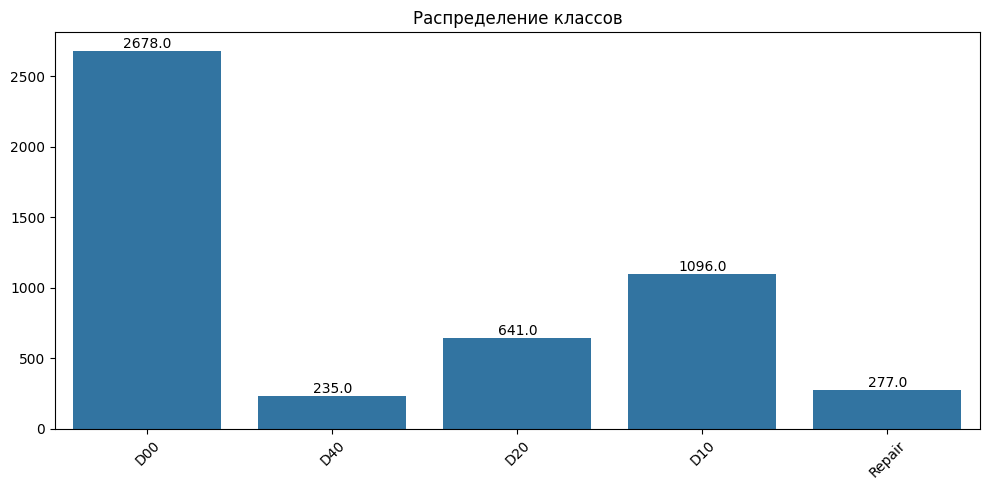

In [401]:
labels = [label for _, _, label in china_dataset.data]
label_counts = Counter(labels)
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=list(label_counts.keys()), y=list(label_counts.values()))
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width()/2, height), ha='center', va='bottom')
plt.title("Распределение классов")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Примеры изображений

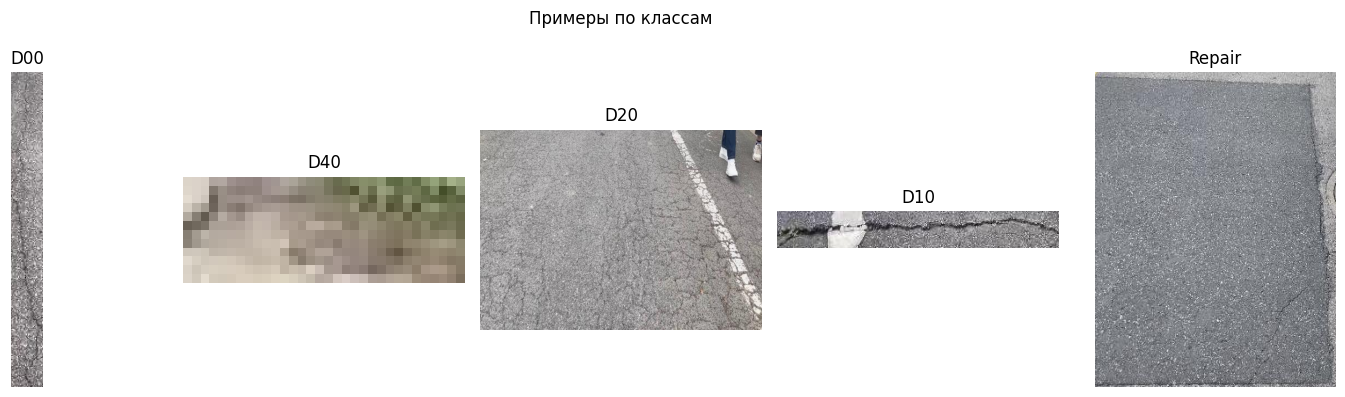

In [402]:
shown = set()
plt.figure(figsize=(15, 4))
i = 1
for img, label in china_dataset:
    if img is None or label in shown:
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, len(label_counts), i)
    plt.imshow(img_rgb)
    plt.title(label)
    plt.axis('off')
    shown.add(label)
    i += 1
    if len(shown) == len(label_counts): break
plt.suptitle("Примеры по классам")
plt.tight_layout()
plt.show()

In [32]:
from sklearn.preprocessing import LabelEncoder
class ClassificationDataSet(Dataset):
    def __init__(self, ds_path):
        self.dataset_path = ds_path
        self.samples = []
        self.targets = []

        ann_dir = os.path.join(self.dataset_path, "annotations/xmls")
        for xml_file in os.listdir(ann_dir):
            tree = ET.parse(os.path.join(ann_dir, xml_file))
            root = tree.getroot()

            for obj in root.findall('object'):
                label = obj.find('name').text
                bndbox = obj.find('bndbox')

                xmin = int(bndbox.find('xmin').text)
                ymin = int(bndbox.find('ymin').text)
                xmax = int(bndbox.find('xmax').text)
                ymax = int(bndbox.find('ymax').text)

                img_dir = os.path.join(self.dataset_path, "images")
                file_name = xml_file.replace(".xml", ".jpg")
                img_path = Path(img_dir) / file_name
                image = cv2.imread(img_path)
                tensor = torch.from_numpy(cv2.resize(image[ymin:ymax, xmin:xmax],(224,224))).float()

                self.samples.append(tensor.permute(2,0,1))
                self.targets.append(label)
        encoder = LabelEncoder()
        self.targets = encoder.fit_transform(self.targets)

    def __getitem__(self, idx):
        return self.samples[idx], self.targets[idx]
    def __len__(self):
        return len(self.targets)

In [33]:
china_dataset = ClassificationDataSet("./CRDD/China_MotorBike/train")

In [34]:
np.unique(china_dataset.targets)

array([0, 1, 2, 3, 4])

In [35]:
china_dataset_size = len(china_dataset)
china_train_size = int(0.8 * china_dataset_size)  # 80% train
china_test_size = china_dataset_size - china_train_size

# Разделение
china_train, china_test = random_split(
    china_dataset, 
    [china_train_size, china_test_size],
    generator=torch.Generator().manual_seed(42)  # Для воспроизводимости
)

In [36]:
model_resnet = resnet18(weights=None)
model_resnet.fc = nn.Linear(model_resnet.fc.in_features, 5) 

In [37]:
# model_resnet = pytorchcv_wrapper.resnet("imagenet", depth=18, pretrained=False)

# model_resnet.output = nn.Linear(model_resnet.output.in_features, 5)

In [38]:
# print(model_resnet)

In [39]:
benchmark_china = nc_benchmark(
    china_train,
    china_test,
    5,
    task_labels=False,
    seed=1234,
    fixed_class_order=[i for i in range(5)],
)

In [40]:
# choose some metrics and evaluation method
interactive_logger = InteractiveLogger()
tensorboard_logger = TensorboardLogger(tb_log_dir="./logs/")

eval_plugin = EvaluationPlugin(
    accuracy_metrics(minibatch=True, epoch=True, experience=True, stream=True),
    loss_metrics(minibatch=True, epoch=True, experience=True, stream=True),
    forgetting_metrics(experience=True),
    loggers=[interactive_logger, tensorboard_logger # wandb_logger
            ],
)

In [41]:
strategy_crdd_naive = Naive(
    model=model_resnet,
    optimizer=torch.optim.SGD(model.parameters(), lr=0.01),
    criterion=CrossEntropyLoss(),
    train_mb_size=100,
    train_epochs=1,
    eval_mb_size=100,
    device=device,
    plugins=[ReplayPlugin(mem_size=1000)],
    evaluator=eval_plugin,
)

In [ ]:
strategy_crdd_ewc = EWC(
    model=model_resnet,
    optimizer=torch.optim.SGD(model.parameters(), lr=0.01),
    criterion=CrossEntropyLoss(),
    ewc_lambda=0.4,
    train_mb_size=100,
    train_epochs=1,
    eval_mb_size=100,
    device=device,
    # plugins=[ReplayPlugin(mem_size=1000)],
    evaluator=eval_plugin,
)

In [ ]:
strategy_crdd_cumulative = Cumulative(
    model=model_resnet,
    optimizer=torch.optim.SGD(model.parameters(), lr=0.01),
    criterion=CrossEntropyLoss(),
    train_mb_size=100,
    train_epochs=1,
    eval_mb_size=100,
    device=device,
    # plugins=[ReplayPlugin(mem_size=1000)],
    evaluator=eval_plugin,
)

In [103]:
# TRAINING LOOP
print("Starting experiment...")
results_crdd_resnet_naive = []
for experience in benchmark_china.train_stream:
    print("Start of experience ", experience.current_experience)
    strategy_crdd_naive.train(experience)
    print("Training completed")

    print("Computing accuracy on the whole test set")
    results_crdd_resnet_naive.append(strategy_crdd_naive.eval(benchmark.test_stream))

In [ ]:
# TRAINING LOOP
print("Starting experiment...")
results_crdd_resnet_ewc = []
for experience in benchmark_china.train_stream:
    print("Start of experience ", experience.current_experience)
    strategy_crdd_ewc.train(experience)
    print("Training completed")

    print("Computing accuracy on the whole test set")
    results_crdd_resnet_ewc.append(strategy_crdd_ewc.eval(benchmark.test_stream))

In [ ]:
# TRAINING LOOP
print("Starting experiment...")
results_crdd_resnet_cumulative = []
for experience in benchmark_china.train_stream:
    print("Start of experience ", experience.current_experience)
    strategy_crdd_cumulative.train(experience)
    print("Training completed")

    print("Computing accuracy on the whole test set")
    results_crdd_resnet_cumulative.append(strategy_crdd_cumulative.eval(benchmark.test_stream))

In [ ]:
metrics_cifar10_alexnet_naive = {
    'accuracy': [],
    'forgetting': []
}

for res in results_cifar10_alexnet_naive:
    for key in res.keys():
        if 'Top1_Acc_Exp' in key:
            metrics_cifar10_alexnet_naive['accuracy'].append(res[key])
        if 'ExperienceForgetting' in key:
            metrics_cifar10_alexnet_naive['forgetting'].append(res[key])

# Permuted MNIST с ResNet

### Загрузка датасета

In [203]:
perm = torch.randperm(28 * 28)

In [204]:
def permute_image(img):
    img = img.view(-1)[perm]
    return img.view(1, 28, 28)

In [205]:
permute_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(permute_image)
])

In [206]:
original_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
pmnist_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=permute_transform)

### Примеры изображений

/home/nikos/anaconda3/envs/myenv3/lib/python3.11/site-packages/matplotlib/cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)


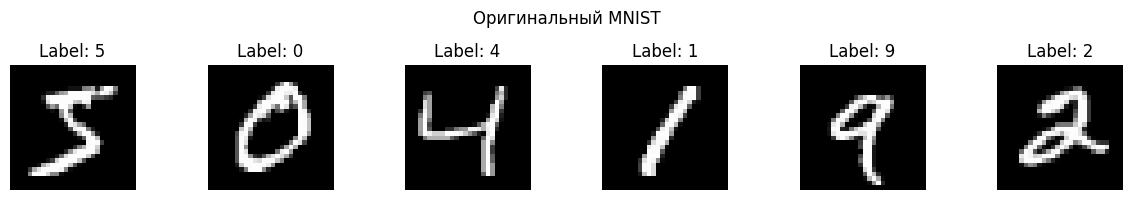

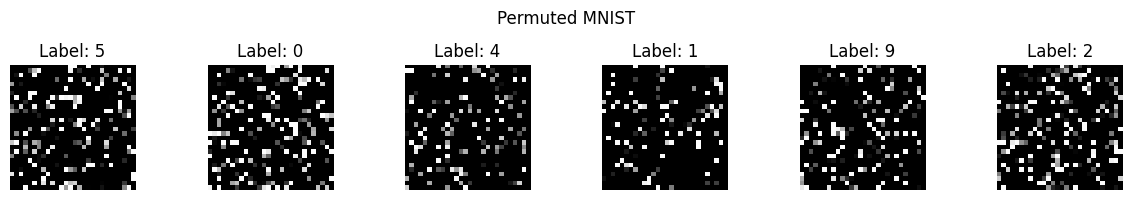

In [207]:
def show_samples(dataset, title, n=6):
    plt.figure(figsize=(12, 2))
    for i in range(n):
        img, label = dataset[i]
        plt.subplot(1, n, i+1)
        plt.imshow(img.squeeze(), cmap='gray')
        plt.title(f"Label: {label}")
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()
show_samples(original_dataset, "Оригинальный MNIST")
show_samples(pmnist_dataset, "Permuted MNIST")

### Распределение классов

/tmp/ipykernel_260862/3353636396.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=labels, palette="Set2")


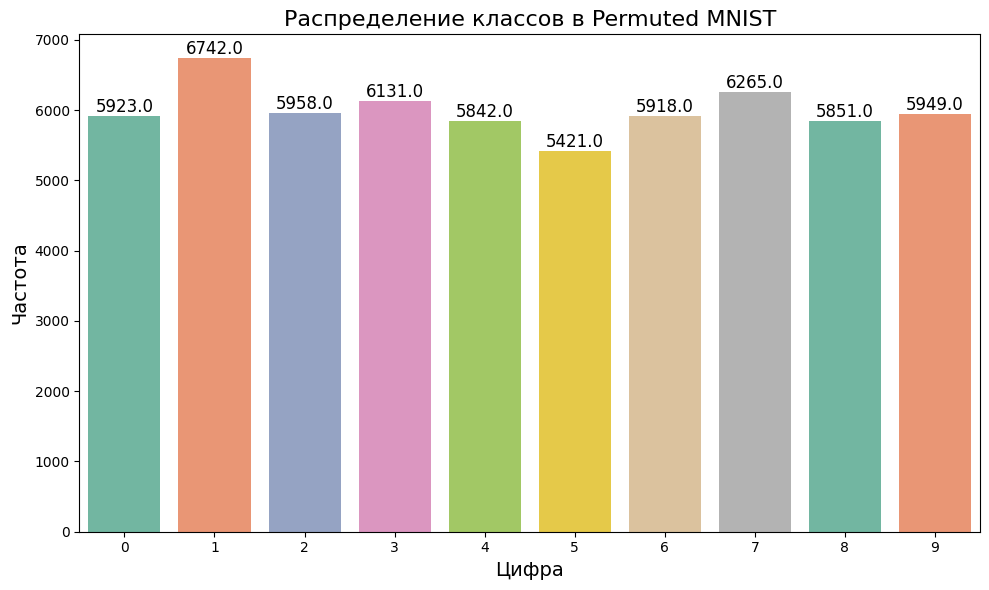

In [208]:
labels = [label for _, label in pmnist_dataset]

plt.figure(figsize=(10, 6))

ax = sns.countplot(x=labels, palette="Set2")
plt.title("Распределение классов в Permuted MNIST", fontsize=16)
plt.xlabel("Цифра", fontsize=14)
plt.ylabel("Частота", fontsize=14)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

In [209]:
pmnist_dataset_size = len(pmnist_dataset)
pmnist_train_size = int(0.8 * pmnist_dataset_size)  # 80% train
pmnist_test_size = pmnist_dataset_size - pmnist_train_size

# Разделение
pmnist_train, pmnist_test = random_split(
    pmnist_dataset, 
    [pmnist_train_size, pmnist_test_size],
    # generator=torch.Generator().manual_seed(42)  # Для воспроизводимости
)

### Создание модели

In [32]:
perm_mnist = PermutedMNIST(n_experiences=5)

perm_train = perm_mnist.train_stream
perm_test = perm_mnist.test_stream

In [45]:
# 1. Создаем исходную модель ResNet-20 для CIFAR-10
model_pmnist_resnet = pytorchcv_wrapper.resnet("cifar10", depth=20, pretrained=False)

# 2. Модифицируем первый сверточный слой для 1 канала (MNIST)
# Доступ к первому Conv2d через init_block.conv
original_conv = model_pmnist_resnet.features.init_block.conv

# Создаем новый Conv2d с 1 входным каналом
model_pmnist_resnet.features.init_block.conv = nn.Conv2d(
    in_channels=1,  # MNIST имеет 1 канал
    out_channels=original_conv.out_channels,
    kernel_size=original_conv.kernel_size,
    stride=original_conv.stride,
    padding=original_conv.padding,
    bias=original_conv.bias is not None
)

# 3. Инициализация весов (копируем из первого канала оригинального)
with torch.no_grad():
    # Копируем веса из первого канала (повторяем для всех выходных каналов)
    for i in range(original_conv.out_channels):
        model_pmnist_resnet.features.init_block.conv.weight[i] = original_conv.weight[i, 0].clone()

# 4. Модифицируем средний пулинг для MNIST (28x28 -> 4x4)
model_pmnist_resnet.features.final_pool = nn.AdaptiveAvgPool2d((1, 1))

# 5. Обновляем выходной слой для 10 классов MNIST
model_pmnist_resnet.output = nn.Linear(
    in_features=64,  # 64 - out_features из архитектуры
    out_features=10   # 10 классов для MNIST
)

# 6. Проверяем архитектуру
# print(model_pmnist_resnet)

In [46]:
# Трансформации для MNIST
mnist_transform = transforms.Compose([
    transforms.Lambda(lambda x: x if isinstance(x, Image.Image) else transforms.ToPILImage()(x)),
    transforms.ToTensor(),
    # transforms.Normalize((0.1307,), (0.3081,))
])

# Создаем benchmark с 5 перестановками
benchmark_pmnist = PermutedMNIST(
    n_experiences=5,
    seed=1234,
    train_transform=mnist_transform,
    eval_transform=mnist_transform
)

In [47]:
# exp = benchmark_pmnist.train_stream[0]
# sample, label, task_label = exp.dataset[0]  # (1, 28, 28)

# # Добавляем batch-размерность
# sample = sample.unsqueeze(0)  # (1, 1, 28, 28)

# # Тестовый forward pass
# model_pmnist_resnet.eval()
# with torch.no_grad():
#     output = model_pmnist_resnet(sample)
#     print(f"Output shape: {output.shape}")  # Должно быть torch.Size([1, 10])

In [48]:
interactive_logger = InteractiveLogger()
tensorboard_logger = TensorboardLogger(tb_log_dir="./logs_pmnist/")

eval_plugin = EvaluationPlugin(
    accuracy_metrics(minibatch=True, epoch=True, experience=True, stream=True),
    loss_metrics(minibatch=True, epoch=True, experience=True, stream=True),
    forgetting_metrics(experience=True),
    loggers=[interactive_logger, tensorboard_logger # wandb_logger
            ],
)

In [37]:
strategy_naive = Naive(
    model=model_pmnist_resnet,
    optimizer=torch.optim.Adam(model_pmnist_resnet.parameters(), lr=0.01),
    criterion=nn.CrossEntropyLoss(),
    train_mb_size=100,
    train_epochs=1,
    eval_mb_size=100,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    evaluator=eval_plugin,
)

In [43]:
strategy_ewc = EWC(
    model=model_pmnist_resnet,
    optimizer=torch.optim.Adam(model_pmnist_resnet.parameters(), lr=0.01),
    criterion=nn.CrossEntropyLoss(),
    ewc_lambda=0.4,
    train_mb_size=100,
    train_epochs=1,
    eval_mb_size=100,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    evaluator=eval_plugin,
)

In [49]:
strategy_cumulative = Cumulative(
    model=model_pmnist_resnet,
    optimizer=torch.optim.Adam(model_pmnist_resnet.parameters(), lr=0.01),
    criterion=nn.CrossEntropyLoss(),
    train_mb_size=100,
    train_epochs=1,
    eval_mb_size=100,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    evaluator=eval_plugin,
)

In [38]:
# TRAINING LOOP
print("Starting experiment...")
results_pmnist_resnet_naive = []
for experience in benchmark_pmnist.train_stream:
    print("Start of experience ", experience.current_experience)
    strategy_naive.train(experience)
    print("Training completed")

    print("Computing accuracy on the whole test set")
    results_pmnist_resnet_naive.append(strategy_naive.eval(benchmark_pmnist.test_stream))

Starting experiment...
Start of experience  0
-- >> Start of training phase << --
100%|█████████████████████████████████████████| 600/600 [00:10<00:00, 59.61it/s]
Epoch 0 ended.
	Loss_Epoch/train_phase/train_stream/Task000 = 0.3209
	Loss_MB/train_phase/train_stream/Task000 = 0.2956
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8980
	Top1_Acc_MB/train_phase/train_stream/Task000 = 0.9400
-- >> End of training phase << --
Training completed
Computing accuracy on the whole test set
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|████████████████████████████████████████| 100/100 [00:00<00:00, 115.34it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	Loss_Exp/eval_phase/test_stream/Task000/Exp000 = 0.1949
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.9423
-- Starting eval on experience 1 (Task 0) from test stream --
100%|████████████████████████████████████████| 100/100 [00:00<00:00, 116.60it/s]
> Eval on experien

In [44]:
# TRAINING LOOP
print("Starting experiment...")
results_pmnist_resnet_ewc = []
for experience in benchmark_pmnist.train_stream:
    print("Start of experience ", experience.current_experience)
    strategy_ewc.train(experience)
    print("Training completed")

    print("Computing accuracy on the whole test set")
    results_pmnist_resnet_ewc.append(strategy_ewc.eval(benchmark_pmnist.test_stream))

Starting experiment...
Start of experience  0
-- >> Start of training phase << --
100%|█████████████████████████████████████████| 600/600 [00:10<00:00, 55.29it/s]
Epoch 0 ended.
	Loss_Epoch/train_phase/train_stream/Task000 = 0.3251
	Loss_MB/train_phase/train_stream/Task000 = 0.1856
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8971
	Top1_Acc_MB/train_phase/train_stream/Task000 = 0.9600
-- >> End of training phase << --
Training completed
Computing accuracy on the whole test set
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|█████████████████████████████████████████| 100/100 [00:01<00:00, 93.54it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	Loss_Exp/eval_phase/test_stream/Task000/Exp000 = 0.3486
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.8924
-- Starting eval on experience 1 (Task 0) from test stream --
100%|████████████████████████████████████████| 100/100 [00:00<00:00, 103.70it/s]
> Eval on experien

In [50]:
# TRAINING LOOP
print("Starting experiment...")
results_pmnist_resnet_cumulative = []
for experience in benchmark_pmnist.train_stream:
    print("Start of experience ", experience.current_experience)
    strategy_cumulative .train(experience)
    print("Training completed")

    print("Computing accuracy on the whole test set")
    results_pmnist_resnet_cumulative .append(strategy_cumulative .eval(benchmark_pmnist.test_stream))

Starting experiment...
Start of experience  0
-- >> Start of training phase << --
100%|█████████████████████████████████████████| 600/600 [00:10<00:00, 56.62it/s]
Epoch 0 ended.
	Loss_Epoch/train_phase/train_stream/Task000 = 0.3214
	Loss_MB/train_phase/train_stream/Task000 = 0.1493
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8975
	Top1_Acc_MB/train_phase/train_stream/Task000 = 0.9300
-- >> End of training phase << --
Training completed
Computing accuracy on the whole test set
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|████████████████████████████████████████| 100/100 [00:00<00:00, 103.19it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	Loss_Exp/eval_phase/test_stream/Task000/Exp000 = 0.3285
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.8954
-- Starting eval on experience 1 (Task 0) from test stream --
100%|████████████████████████████████████████| 100/100 [00:00<00:00, 109.51it/s]
> Eval on experien

In [353]:
metrics_pmnist_resnet_naive = {
    'accuracy': [],
    'forgetting': []
}

for res in results_pmnist_resnet_naive:
    for key in res.keys():
        if 'Top1_Acc_Exp' in key:
            metrics_pmnist_resnet_naive['accuracy'].append(res[key])
        if 'ExperienceForgetting' in key:
            metrics_pmnist_resnet_naive['forgetting'].append(res[key])

In [360]:
metrics_pmnist_resnet_ewc = {
    'accuracy': [],
    'forgetting': []
}

for res in results_pmnist_resnet_ewc:
    for key in res.keys():
        if 'Top1_Acc_Exp' in key:
            metrics_pmnist_resnet_ewc['accuracy'].append(res[key])
        if 'ExperienceForgetting' in key:
            metrics_pmnist_resnet_ewc['forgetting'].append(res[key])

In [367]:
metrics_pmnist_resnet_cumulative = {
    'accuracy': [],
    'forgetting': []
}

for res in results_pmnist_resnet_cumulative:
    for key in res.keys():
        if 'Top1_Acc_Exp' in key:
            metrics_pmnist_resnet_cumulative['accuracy'].append(res[key])
        if 'ExperienceForgetting' in key:
            metrics_pmnist_resnet_cumulative['forgetting'].append(res[key])

In [368]:
metrics_pmnist_resnet_naive

{'accuracy': [0.9225,
  0.078,
  0.1086,
  0.0908,
  0.0917,
  0.4938,
  0.9503,
  0.1443,
  0.1064,
  0.1245,
  0.1337,
  0.3931,
  0.9497,
  0.1014,
  0.117,
  0.0952,
  0.1408,
  0.3849,
  0.9419,
  0.1009,
  0.1811,
  0.1663,
  0.2784,
  0.6299,
  0.9386],
 'forgetting': [0.42869999999999997,
  0.7888,
  0.5572,
  0.8272999999999999,
  0.8095,
  0.5648,
  0.7414,
  0.784,
  0.6713,
  0.31199999999999994]}

In [369]:
metrics_pmnist_resnet_ewc

{'accuracy': [0.9427,
  0.1398,
  0.1327,
  0.1099,
  0.0917,
  0.5664,
  0.9434,
  0.1445,
  0.0786,
  0.1114,
  0.2803,
  0.6263,
  0.9458,
  0.0597,
  0.1316,
  0.1416,
  0.2735,
  0.4084,
  0.9436,
  0.0888,
  0.1334,
  0.2032,
  0.2208,
  0.4611,
  0.9377],
 'forgetting': [0.37629999999999997,
  0.6624,
  0.31710000000000005,
  0.8010999999999999,
  0.6698999999999999,
  0.5374,
  0.8093,
  0.7402,
  0.725,
  0.4825]}

In [370]:
metrics_pmnist_resnet_cumulative

{'accuracy': [0.9326,
  0.0943,
  0.0991,
  0.1018,
  0.1369,
  0.9508,
  0.9466,
  0.1601,
  0.0619,
  0.104,
  0.9531,
  0.9512,
  0.9451,
  0.0985,
  0.1281,
  0.9583,
  0.9492,
  0.9555,
  0.945,
  0.153,
  0.9552,
  0.9558,
  0.9523,
  0.9519,
  0.9483],
 'forgetting': [-0.018199999999999994,
  -0.020499999999999963,
  -0.0046000000000000485,
  -0.025700000000000056,
  -0.0026000000000000467,
  -0.010399999999999965,
  -0.022600000000000064,
  -0.009199999999999986,
  -0.007199999999999984,
  -0.006900000000000017]}

In [75]:
for res in results_cifar10_alexnet_naive:
    for key in res.keys():
        if 'Top1_Acc_Exp' in key:
            print(key, res[key])

Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 0.5
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001 0.0
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp002 0.0
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp003 0.0
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp004 0.0
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 0.312
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001 0.408
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp002 0.0
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp003 0.0
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp004 0.0
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 0.258
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001 0.0
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp002 0.4775
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp003 0.0
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp004 0.0
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 0.0
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001 0.0
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp002 0.0
T

In [80]:
for res in results_pmnist_resnet_cumulative:
    for key in res.keys():
        if 'Top1_Acc_Exp' in key:
            print(key, res[key])

Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 0.8954
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001 0.1232
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp002 0.0837
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp003 0.1027
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp004 0.112
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 0.9494
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001 0.9357
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp002 0.1685
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp003 0.1831
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp004 0.1201
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 0.933
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001 0.9442
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp002 0.9394
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp003 0.1673
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp004 0.1374
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 0.9605
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001 0.9455
Top1_Acc_Exp/eva

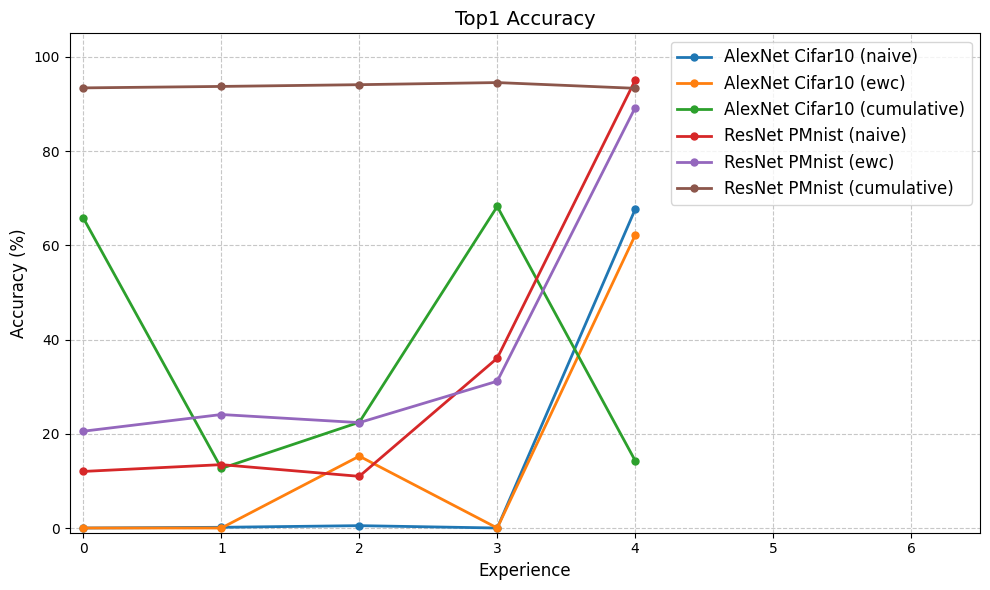

In [86]:
plt.figure(figsize=(10, 6))  # Размер графика

# Рисуем все графики на одном поле
plt.plot([0, 1, 2, 3, 4], np.array([0.0, 0.0015, 0.005, 0.0, 0.6765]) * 100,'o-', markersize=5, label='AlexNet Cifar10 (naive)', linewidth=2)
plt.plot([0, 1, 2, 3, 4], np.array([0.0, 0.0, 0.1525, 0.0, 0.6215]) * 100, 'o-', markersize=5, label='AlexNet Cifar10 (ewc)', linewidth=2)
plt.plot([0, 1, 2, 3, 4], np.array([0.6575, 0.1265, 0.2245, 0.6825, 0.143]) * 100, 'o-', markersize=5, label='AlexNet Cifar10 (cumulative)', linewidth=2)

plt.plot([0, 1, 2, 3, 4], np.array([0.1201, 0.1345, 0.1097, 0.3605, 0.9504]) * 100,'o-', markersize=5, label='ResNet PMnist (naive)', linewidth=2)
plt.plot([0, 1, 2, 3, 4], np.array([0.2055, 0.2409, 0.2237, 0.3116, 0.8922]) * 100, 'o-', markersize=5, label='ResNet PMnist (ewc)', linewidth=2)
plt.plot([0, 1, 2, 3, 4], np.array([0.9342, 0.9373, 0.941, 0.9455, 0.9333]) * 100, 'o-', markersize=5, label='ResNet PMnist (cumulative)', linewidth=2)

# Добавляем заголовок и подписи осей
plt.title('Top1 Accuracy', fontsize=14)
plt.xlabel('Experience', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)

# Включаем сетку и легенду
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12, loc='upper right')

# Настраиваем диапазон осей (опционально)
plt.xlim(-0.1, 6.5)
plt.ylim(-1, 105)

# Показываем график
plt.tight_layout()  # Чтобы избежать наложения элементов
plt.savefig(
    'Accuracy.png',          # Имя файла
    # dpi=300,               # Качество (точек на дюйм)
    # bbox_inches='tight',   # Обрезать пустые поля
    # pad_inches=0.3,        # Отступ вокруг графика
    # facecolor='white',     # Фон
    # edgecolor='none'       # Без рамки
)
plt.show()

In [87]:
for res in results_cifar10_alexnet_naive:
    for key in res.keys():
        if 'Forget' in key:
            print(key, res[key])

ExperienceForgetting/eval_phase/test_stream/Task000/Exp000 0.188
ExperienceForgetting/eval_phase/test_stream/Task000/Exp000 0.242
ExperienceForgetting/eval_phase/test_stream/Task000/Exp001 0.408
ExperienceForgetting/eval_phase/test_stream/Task000/Exp000 0.5
ExperienceForgetting/eval_phase/test_stream/Task000/Exp001 0.408
ExperienceForgetting/eval_phase/test_stream/Task000/Exp002 0.4775
ExperienceForgetting/eval_phase/test_stream/Task000/Exp000 0.5
ExperienceForgetting/eval_phase/test_stream/Task000/Exp001 0.4065
ExperienceForgetting/eval_phase/test_stream/Task000/Exp002 0.4725
ExperienceForgetting/eval_phase/test_stream/Task000/Exp003 0.728


In [94]:
results_pmnist_resnet_cumulative

[{'Top1_Acc_MB/train_phase/train_stream/Task000': 0.93,
  'Loss_MB/train_phase/train_stream/Task000': 0.14933925867080688,
  'Top1_Acc_Epoch/train_phase/train_stream/Task000': 0.8975333333333333,
  'Loss_Epoch/train_phase/train_stream/Task000': 0.3214179336403807,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000': 0.8954,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp000': 0.3285190344415605,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001': 0.1232,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp001': 3.923375358581543,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp002': 0.0837,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp002': 3.8115335047245025,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp003': 0.1027,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp003': 4.798592677116394,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp004': 0.112,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp004': 3.9650134164094926,
  'Top1_Acc_Stream/eval_phase/test_stream/Task000': 0.2634

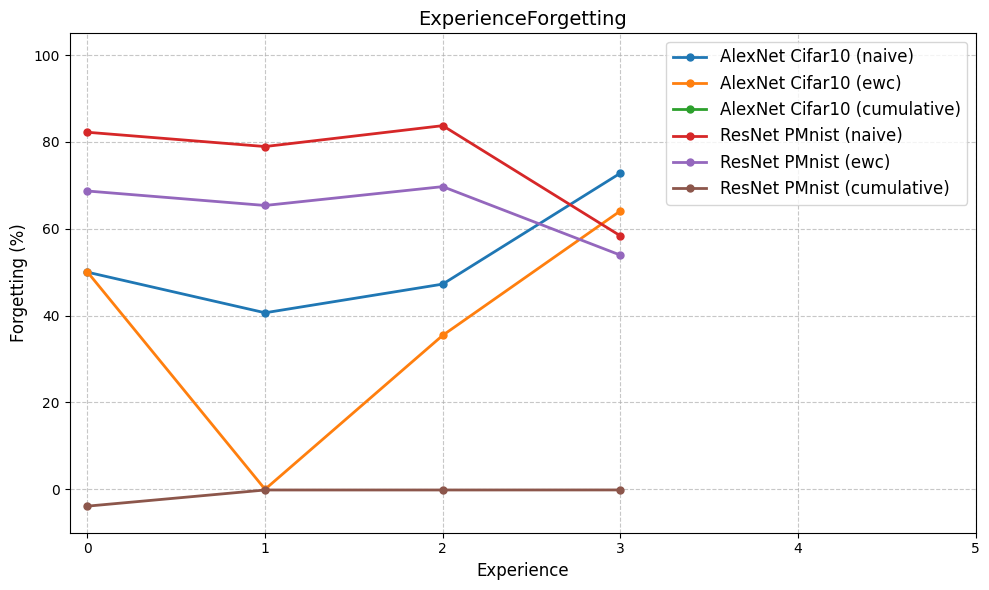

In [102]:
plt.figure(figsize=(10, 6))  # Размер графика

# Рисуем все графики на одном поле
plt.plot([0, 1, 2, 3], np.array([0.5, 0.4065, 0.4725, 0.728]) * 100,'o-', markersize=5, label='AlexNet Cifar10 (naive)', linewidth=2)
plt.plot([0, 1, 2, 3], np.array([0.5005, 0.0, 0.3545, 0.641]) * 100, 'o-', markersize=5, label='AlexNet Cifar10 (ewc)', linewidth=2)
plt.plot([0, 1, 2, 3], np.array([-0.15749, -0.1265, 0-0.2245, -0.578]) * 100, 'o-', markersize=5, label='AlexNet Cifar10 (cumulative)', linewidth=2)

plt.plot([0, 1, 2, 3], np.array([0.8222, 0.78929, 0.8374, 0.5837]) * 100,'o-', markersize=5, label='ResNet PMnist (naive)', linewidth=2)
plt.plot([0, 1, 2, 3], np.array([0.6869, 0.6536, 0.697, 0.5393]) * 100, 'o-', markersize=5, label='ResNet PMnist (ewc)', linewidth=2)
plt.plot([0, 1, 2, 3], np.array([-0.0388, -0.0016, -0.00159, -0.0015]) * 100, 'o-', markersize=5, label='ResNet PMnist (cumulative)', linewidth=2)

# Добавляем заголовок и подписи осей
plt.title('ExperienceForgetting', fontsize=14)
plt.xlabel('Experience', fontsize=12)
plt.ylabel('Forgetting (%)', fontsize=12)

# Включаем сетку и легенду
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12, loc='upper right')

# Настраиваем диапазон осей (опционально)
plt.xlim(-0.1, 5)
plt.ylim(-10, 105)

# Показываем график
plt.tight_layout()  # Чтобы избежать наложения элементов
plt.savefig(
    'Forgetting.png'
)
plt.show()